In [52]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [53]:
#read in .pt
agent_data = torch.load("reward_shaping_datasets/agent_state_action_dataset.pt")

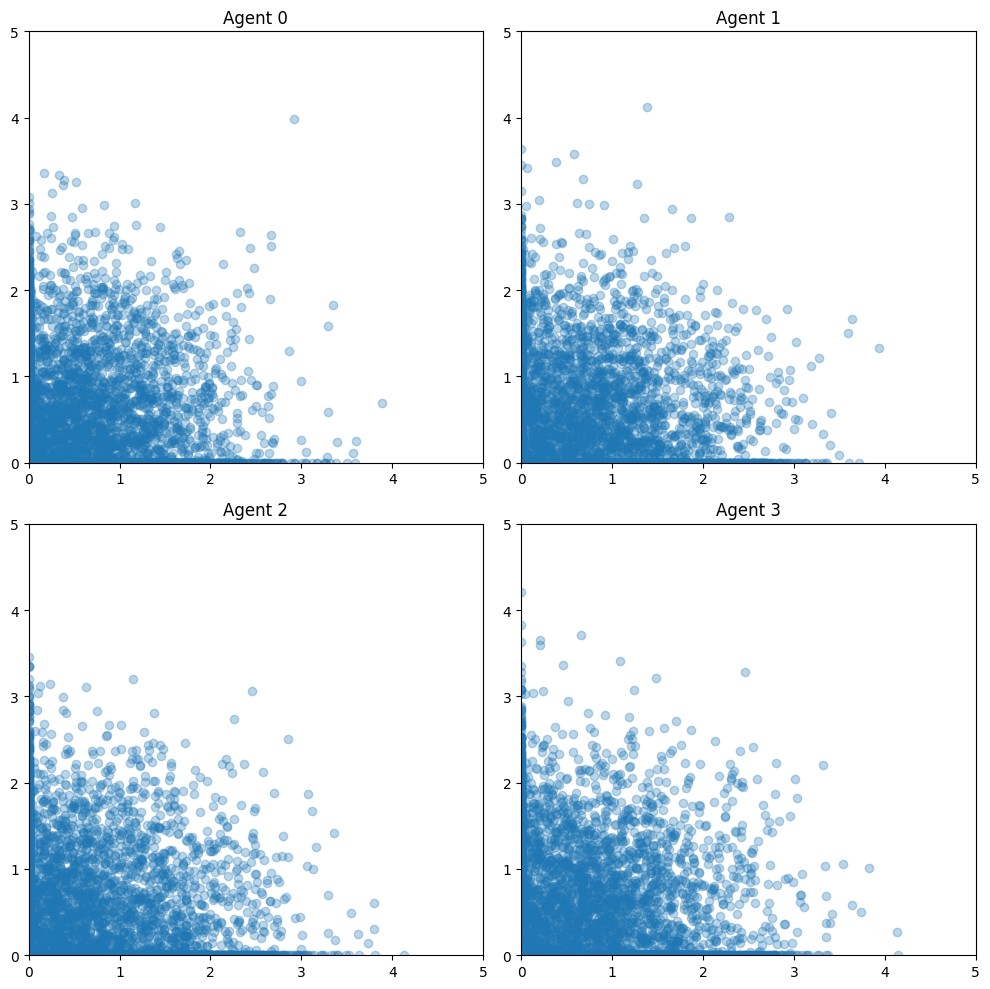

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.scatter(agent_data[i, :, 7], agent_data[i, :, 8], alpha=0.3)
    ax.set_xlim(0, 5)  # Set x-axis limits
    ax.set_ylim(0, 5)  # Set y-axis limits
    ax.set_title(f"Agent {i}")

plt.tight_layout()
plt.show()

In [55]:
for agent_idx in range(agent_data.shape[0]):
    agent_stats = {
        "mean": agent_data[agent_idx].mean(dim=0)[7:],
        "std": agent_data[agent_idx].std(dim=0)[7:]
    }
    print(f"Agent {agent_idx} statistics:")
    for stat_name, stat_value in agent_stats.items():
        print(f"  {stat_name}: {stat_value}")
    print()

Agent 0 statistics:
  mean: tensor([0.4743, 0.3854])
  std: tensor([0.6259, 0.5833])

Agent 1 statistics:
  mean: tensor([0.5114, 0.3837])
  std: tensor([0.6813, 0.5771])

Agent 2 statistics:
  mean: tensor([0.5057, 0.4009])
  std: tensor([0.6914, 0.5946])

Agent 3 statistics:
  mean: tensor([0.5091, 0.4423])
  std: tensor([0.6834, 0.6188])



In [56]:
from scipy.stats import wasserstein_distance

# Extract the relevant data
data1 = agent_data[0, :, 7:].numpy().flatten()
data2 = agent_data[1, :, 7:].numpy().flatten()

# Calculate the Wasserstein distance
distance = wasserstein_distance(data1, data2)
print(f"Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: {distance}")

Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: 0.018973230605074456


In [57]:
# Extract the relevant data
data1 = agent_data[1, :, 7:].numpy().flatten()
data2 = agent_data[3, :, 7:].numpy().flatten()

# Calculate the Wasserstein distance
distance = wasserstein_distance(data1, data2)
print(f"Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: {distance}")

Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: 0.028165496624160374


In [58]:
# Extract the relevant data
data1 = agent_data[3, :, 7:].numpy().flatten()
data2 = agent_data[0, :, 7:].numpy().flatten()

# Calculate the Wasserstein distance
distance = wasserstein_distance(data1, data2)
print(f"Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: {distance}")

Wasserstein distance between agent_data[0, :, 7:] and agent_data[1, :, 7:]: 0.045868288308797064
